In [ ]:
!unzip "/content/drive/MyDrive/digital_knee_x-ray_ds.zip"

Archive:  /content/drive/MyDrive/digital_knee_x-ray_ds.zip
  inflating: MedicalExpert-I/0Normal/NormalG0 (1).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (10).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (100).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (101).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (102).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (103).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (104).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (105).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (106).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (107).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (108).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (109).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (11).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (110).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (111).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (112).png  
  inflating: Medi

In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [ ]:
def read_data(path,image_size,classes):

    X=[]
    y=[]

    for label in os.listdir(path):

        for img_name in os.listdir(os.path.join(path,label)):

            img=cv2.imread(os.path.join(path,label,img_name))
            img=cv2.resize(img,(image_size,image_size))
            img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

            X.append(img)
            y.append(classes[label])

    return np.array(X),np.array(y)

In [ ]:
knee_classes = {
    '0Normal': 0,
    '1Doubtful': 1,
    '2Mild': 2,
    '3Moderate': 3,
    '4Severe': 4
}

In [ ]:
image_size = 224

x1, y1 = read_data('/content/MedicalExpert-I', image_size, knee_classes)
x2, y2 = read_data('/content/MedicalExpert-II', image_size, knee_classes)

X = np.concatenate((x1, x2))
y = np.concatenate((y1, y2))

X, y = shuffle(X, y, random_state=42)

print("Dataset shape:", X.shape)

Dataset shape: (3300, 224, 224, 3)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [ ]:
x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)

In [ ]:
y_train = to_categorical(y_train,5)
y_test = to_categorical(y_test,5)

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

datagen.fit(x_train)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.6608811748998665), 1: np.float64(0.6591211717709721), 2: np.float64(1.430635838150289), 3: np.float64(1.5372670807453417), 4: np.float64(1.6123778501628665)}


In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
for layer in base_model.layers[:-50]:
    layer.trainable = False

for layer in base_model.layers[-50:]:
    layer.trainable = True

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)

output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,838,056 (18.46 MB)

 Trainable params: 3,315,349 (12.65 MB)

 Non-trainable params: 1,522,707 (5.81 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    validation_data=(x_test, y_test),
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 116s 961ms/step - accuracy: 0.2182 - loss: 1.6244 - val_accuracy: 0.3006 - val_loss: 1.5552
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 35s 445ms/step - accuracy: 0.3446 - loss: 1.4938 - val_accuracy: 0.4036 - val_loss: 1.4322
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 35s 448ms/step - accuracy: 0.3863 - loss: 1.4155 - val_accuracy: 0.4327 - val_loss: 1.3258
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 34s 431ms/step - accuracy: 0.4081 - loss: 1.3601 - val_accuracy: 0.4545 - val_loss: 1.2472
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 36s 456ms/step - accuracy: 0.4291 - loss: 1.2903 - val_accuracy: 0.4885 - val_loss: 1.1829
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 34s 435ms/step - accuracy: 0.4558 - loss: 1.2408 - val_accuracy: 0.5382 - val_loss: 1.1287
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 36s 464ms/step - accuracy: 0.5224 - loss: 1.1897 - val_accuracy: 0.5745 - val_loss: 1.0728
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 34s 437ms/step - accuracy: 0.5156 - loss: 1.1542 - val_acc

In [ ]:
loss, acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", acc)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7879 - loss: 0.4954
Test Accuracy: 0.7878788113594055


26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 451ms/step


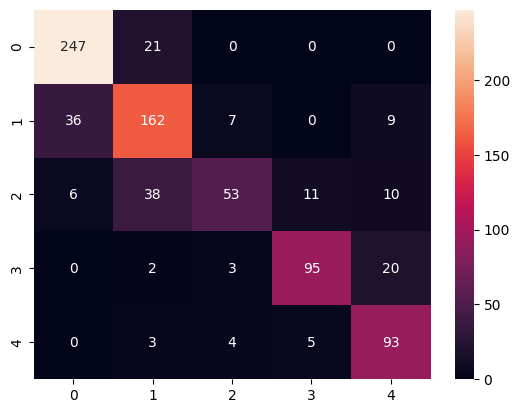

              precision    recall  f1-score   support

           0       0.85      0.92      0.89       268
           1       0.72      0.76      0.74       214
           2       0.79      0.45      0.57       118
           3       0.86      0.79      0.82       120
           4       0.70      0.89      0.78       105

    accuracy                           0.79       825
   macro avg       0.78      0.76      0.76       825
weighted avg       0.79      0.79      0.78       825



In [ ]:
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, annot=True, fmt="d")
plt.show()

print(classification_report(y_true, y_pred_classes))

In [ ]:
model.save("knee_final_efficientnet_model.h5")